<a href="https://colab.research.google.com/github/hypro2/hands-on-LLM-from-colab/blob/main/turboquant_pytorch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/tonbistudio/turboquant-pytorch.git

Cloning into 'turboquant-pytorch'...
remote: Enumerating objects: 24, done.
remote: Counting objects: 100% (20/20), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 24 (delta 5), reused 12 (delta 4), pack-reused 4 (from 1)
Receiving objects: 100% (24/24), 38.09 KiB | 3.81 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [2]:
!pip install torch --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128


In [3]:
!cd /content/turboquant-pytorch && pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 16.2 MB/s eta 0:00:00


In [17]:
import sys
sys.path.insert(0, '/content')

# TurboQuant 핵심 알고리즘 사용 예시 (synthetic validation)
from turboquant_pytorch.turboquant import TurboQuantMSE, TurboQuantProd
import torch

# 벡터 생성 (KV 캐시 시뮬레이션)
d = 128  # 차원
n = 1000  # 벡터 수
vectors = torch.randn(n, d)

# 3비트 양자화 설정
tq = TurboQuantProd(bits=3, d=d)

# 압축 및 복원
compressed = tq.quantize(vectors)
reconstructed = tq.dequantize(compressed)
print(compressed)
print(reconstructed)


# 내적 정확도 확인 (어텐션 계산용)
query = torch.randn(1, d)
true_attn = query @ vectors.T
approx_attn = tq.inner_product(query, compressed)
print(approx_attn)

{'mse_indices': tensor([[3, 2, 0,  ..., 3, 3, 0],
        [3, 0, 1,  ..., 0, 3, 3],
        [0, 0, 3,  ..., 3, 3, 1],
        ...,
        [0, 0, 0,  ..., 3, 3, 0],
        [0, 0, 0,  ..., 3, 0, 3],
        [3, 0, 0,  ..., 0, 2, 0]]), 'qjl_signs': tensor([[-1.,  1.,  1.,  ..., -1.,  1., -1.],
        [ 1., -1., -1.,  ...,  1., -1.,  1.],
        [-1.,  1.,  1.,  ..., -1., -1., -1.],
        ...,
        [ 1.,  1.,  1.,  ...,  1., -1.,  1.],
        [ 1.,  1.,  1.,  ...,  1., -1.,  1.],
        [ 1.,  1.,  1.,  ..., -1., -1.,  1.]]), 'residual_norm': tensor([ 9.4875, 10.1581,  9.6425,  8.9434, 11.3130,  8.6271, 10.6977, 10.4146,
        11.2047, 10.2981,  9.3089, 10.2734, 11.2798, 11.3471, 10.0380, 10.1351,
         9.8152, 10.2756,  9.6829, 10.0728, 11.0630, 10.6827,  9.1188, 11.4939,
        10.4269,  9.3784,  9.7399, 10.3071,  9.7182,  9.3766,  7.5882, 11.1376,
        11.5350, 10.6424, 10.3679, 11.3957,  8.9871, 10.9802,  8.4917,  9.4901,
         9.8539, 10.3237, 11.1433, 10.4971, 

In [22]:
"""
Verification script for TurboQuant implementation.
Tests MSE distortion bounds, inner product accuracy, and compression ratios
against theoretical predictions from the paper.
"""

import torch
import math
import time
import os
import sys

from turboquant_pytorch.turboquant import TurboQuantMSE, TurboQuantProd, TurboQuantKVCache, LloydMaxCodebook


def test_lloyd_max_codebook():
    """Verify codebook properties for various dimensions and bit-widths."""
    print("=" * 60)
    print("TEST 1: Lloyd-Max Codebook Properties")
    print("=" * 60)

    for d in [64, 128, 256]:
        for bits in [1, 2, 3, 4]:
            cb = LloydMaxCodebook(d, bits)
            print(f"  d={d:>4d}, bits={bits}: {cb.n_levels} levels, "
                  f"distortion/coord={cb.distortion:.6f}, "
                  f"centroids range=[{cb.centroids.min():.4f}, {cb.centroids.max():.4f}]")

    # Verify symmetry (centroids should be symmetric around 0)
    cb = LloydMaxCodebook(128, 3)
    centroid_sum = cb.centroids.sum().abs().item()
    print(f"\n  Symmetry check (d=128, b=3): sum of centroids = {centroid_sum:.6f} (should be ~0)")
    assert centroid_sum < 0.01, "Centroids should be symmetric!"
    print("  PASSED\n")


def test_mse_quantizer():
    """Verify MSE distortion on random unit vectors."""
    print("=" * 60)
    print("TEST 2: MSE Quantizer Distortion")
    print("=" * 60)

    d = 128
    n_vectors = 1000
    device = "cpu"

    for bits in [1, 2, 3, 4]:
        quantizer = TurboQuantMSE(d, bits, seed=42, device=device)

        # Generate random unit vectors
        x = torch.randn(n_vectors, d, device=device)
        x = x / torch.norm(x, dim=-1, keepdim=True)

        # Quantize and reconstruct
        x_hat, indices = quantizer(x)

        # Compute empirical MSE
        mse = ((x - x_hat) ** 2).sum(dim=-1).mean().item()

        # Theoretical upper bound from paper: D_mse <= sqrt(3)*pi/2 * (1/4^b)
        theoretical_bound = math.sqrt(3) * math.pi / 2 * (1 / (4 ** bits))

        ratio = mse / theoretical_bound
        status = "OK" if ratio <= 1.5 else "WARN"  # allow some slack for finite d

        print(f"  bits={bits}: MSE={mse:.6f}, theory_bound={theoretical_bound:.6f}, "
              f"ratio={ratio:.3f} [{status}]")

    print()


def test_inner_product_unbiasedness():
    """Verify that TurboQuantProd gives unbiased inner product estimates."""
    print("=" * 60)
    print("TEST 3: Inner Product Unbiasedness (QJL Correction)")
    print("=" * 60)

    d = 128
    n_trials = 2000
    device = "cpu"

    for bits in [2, 3, 4]:
        quantizer = TurboQuantProd(d, bits, seed=42, device=device)

        # Generate pairs of random unit vectors
        x = torch.randn(n_trials, d, device=device)
        x = x / torch.norm(x, dim=-1, keepdim=True)
        y = torch.randn(n_trials, d, device=device)
        y = y / torch.norm(y, dim=-1, keepdim=True)

        # True inner products
        true_ip = (x * y).sum(dim=-1)

        # Quantize x, compute estimated inner products
        compressed = quantizer.quantize(x)
        estimated_ip = quantizer.inner_product(y, compressed)

        # Check bias (should be near 0)
        bias = (estimated_ip - true_ip).mean().item()
        # Check RMSE
        rmse = ((estimated_ip - true_ip) ** 2).mean().sqrt().item()
        # Correlation
        correlation = torch.corrcoef(torch.stack([true_ip, estimated_ip]))[0, 1].item()

        # Theoretical distortion bound: D_prod <= sqrt(3)*pi^2/d * (1/4^b)
        theoretical_distortion = math.sqrt(3) * math.pi ** 2 / d * (1 / (4 ** bits))

        print(f"  bits={bits}: bias={bias:+.6f}, RMSE={rmse:.6f}, "
              f"corr={correlation:.4f}, theory_D={theoretical_distortion:.6f}")

    print()


def test_mse_only_inner_product_bias():
    """Show that MSE-only quantizer has biased inner products (motivating QJL)."""
    print("=" * 60)
    print("TEST 4: MSE-Only Inner Product Bias (motivation for QJL)")
    print("=" * 60)

    d = 128
    n_trials = 2000
    device = "cpu"

    for bits in [1, 2, 3]:
        quantizer = TurboQuantMSE(d, bits, seed=42, device=device)

        x = torch.randn(n_trials, d, device=device)
        x = x / torch.norm(x, dim=-1, keepdim=True)
        y = torch.randn(n_trials, d, device=device)
        y = y / torch.norm(y, dim=-1, keepdim=True)

        true_ip = (x * y).sum(dim=-1)
        x_hat, _ = quantizer(x)
        mse_ip = (x_hat * y).sum(dim=-1)

        bias = (mse_ip - true_ip).mean().item()
        # The bias factor for 1-bit is ~2/pi = 0.637, so ip is scaled by that
        scale_factor = (mse_ip.mean() / true_ip.mean()).item() if true_ip.mean().abs() > 0.01 else float('nan')

        print(f"  bits={bits}: bias={bias:+.6f} (MSE-only is biased, QJL fixes this)")

    print()


def test_kv_cache():
    """Test the KV cache wrapper with compression ratios."""
    print("=" * 60)
    print("TEST 5: KV Cache Compression Ratios")
    print("=" * 60)

    d_key = 128
    d_value = 128
    seq_len = 1024
    device = "cpu"

    for bits in [2, 3, 4]:
        cache = TurboQuantKVCache(d_key, d_value, bits=bits, seed=42, device=device)

        # Simulate appending KV pairs
        keys = torch.randn(seq_len, d_key, device=device)
        values = torch.randn(seq_len, d_value, device=device)

        cache.append(keys, values)

        usage = cache.memory_usage_bits()
        print(f"  bits={bits}: compression={usage['compression_ratio']:.2f}x "
              f"({usage['total_bits'] / 8 / 1024:.1f} KB vs "
              f"{usage['fp16_bits'] / 8 / 1024:.1f} KB fp16)")

        # Test attention score computation
        query = torch.randn(1, d_key, device=device)
        scores = cache.attention_scores(query)
        print(f"           attention scores shape: {scores.shape}, "
              f"range=[{scores.min():.3f}, {scores.max():.3f}]")

    print()


def test_needle_in_haystack():
    """
    Simplified needle-in-haystack: hide a specific key among many,
    verify we can still find it via attention after quantization.
    """
    print("=" * 60)
    print("TEST 6: Needle-in-Haystack Retrieval")
    print("=" * 60)

    d = 128
    device = "cpu"

    for bits in [2, 3, 4]:
        for seq_len in [512, 2048, 8192]:
            # Create random keys
            keys = torch.randn(seq_len, d, device=device)
            keys = keys / torch.norm(keys, dim=-1, keepdim=True)

            # Pick a random "needle" position and create a query that matches it
            needle_pos = seq_len // 3
            query = keys[needle_pos].clone().unsqueeze(0)  # exact match query

            # Quantize all keys
            quantizer = TurboQuantProd(d, bits, seed=42, device=device)
            compressed = quantizer.quantize(keys)

            # Compute inner products
            estimated_ips = quantizer.inner_product(
                query.expand(seq_len, -1), compressed
            )

            # Check if needle is still the top result
            top_idx = estimated_ips.argmax().item()
            found = top_idx == needle_pos

            # Also check top-5
            top5 = estimated_ips.topk(5).indices.tolist()
            in_top5 = needle_pos in top5

            status = "EXACT" if found else ("TOP-5" if in_top5 else "MISS")
            print(f"  bits={bits}, seq={seq_len:>5d}: top1={top_idx:>5d} "
                  f"(needle={needle_pos:>5d}) [{status}]")

    print()


def test_gpu_if_available():
    """Run a quick benchmark on GPU if CUDA is available."""
    print("=" * 60)
    print("TEST 7: GPU Benchmark (if CUDA available)")
    print("=" * 60)

    if not torch.cuda.is_available():
        print("  CUDA not available, skipping GPU test")
        print()
        return

    device = "cuda"
    d = 128
    bits = 3
    seq_len = 8192
    n_queries = 64

    print(f"  GPU: {torch.cuda.get_device_name()}")
    print(f"  Config: d={d}, bits={bits}, seq_len={seq_len}, n_queries={n_queries}")

    quantizer = TurboQuantProd(d, bits, seed=42, device=device)

    # Generate data
    keys = torch.randn(seq_len, d, device=device)
    keys = keys / torch.norm(keys, dim=-1, keepdim=True)
    queries = torch.randn(n_queries, d, device=device)
    queries = queries / torch.norm(queries, dim=-1, keepdim=True)

    # Benchmark quantization
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(10):
        compressed = quantizer.quantize(keys)
    torch.cuda.synchronize()
    quant_time = (time.perf_counter() - t0) / 10
    print(f"  Quantize {seq_len} keys: {quant_time * 1000:.2f} ms")

    # Benchmark inner product
    compressed = quantizer.quantize(keys)
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(100):
        for i in range(n_queries):
            ip = quantizer.inner_product(queries[i:i+1].expand(seq_len, -1), compressed)
    torch.cuda.synchronize()
    ip_time = (time.perf_counter() - t0) / 100
    print(f"  Inner product ({n_queries} queries x {seq_len} keys): {ip_time * 1000:.2f} ms")

    # Compare with full-precision
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    for _ in range(100):
        fp_scores = queries @ keys.T
    torch.cuda.synchronize()
    fp_time = (time.perf_counter() - t0) / 100
    print(f"  Full-precision matmul: {fp_time * 1000:.2f} ms")

    # Memory comparison
    fp16_bytes = seq_len * d * 2  # fp16
    quant_bytes = seq_len * d * bits / 8
    print(f"  Memory: {fp16_bytes / 1024:.1f} KB (fp16) vs {quant_bytes / 1024:.1f} KB (TQ-{bits}bit)")
    print(f"  Compression: {fp16_bytes / quant_bytes:.1f}x")
    print()


if __name__ == "__main__":
    print()
    print("TurboQuant Implementation Verification")
    print("Based on: 'TurboQuant: Online Vector Quantization' (ICLR 2026)")
    print()

    test_lloyd_max_codebook()
    test_mse_quantizer()
    test_inner_product_unbiasedness()
    test_mse_only_inner_product_bias()
    test_kv_cache()
    test_needle_in_haystack()
    test_gpu_if_available()

    print("=" * 60)
    print("ALL TESTS COMPLETE")
    print("=" * 60)


TurboQuant Implementation Verification
Based on: 'TurboQuant: Online Vector Quantization' (ICLR 2026)

TEST 1: Lloyd-Max Codebook Properties
  d=  64, bits=1: 2 levels, distortion/coord=0.005678, centroids range=[-0.0997, 0.0997]
  d=  64, bits=2: 4 levels, distortion/coord=0.001836, centroids range=[-0.1888, 0.1888]
  d=  64, bits=3: 8 levels, distortion/coord=0.000540, centroids range=[-0.2690, 0.2690]
  d=  64, bits=4: 16 levels, distortion/coord=0.000148, centroids range=[-0.3416, 0.3416]
  d= 128, bits=1: 2 levels, distortion/coord=0.002839, centroids range=[-0.0705, 0.0705]
  d= 128, bits=2: 4 levels, distortion/coord=0.000918, centroids range=[-0.1335, 0.1335]
  d= 128, bits=3: 8 levels, distortion/coord=0.000270, centroids range=[-0.1902, 0.1902]
  d= 128, bits=4: 16 levels, distortion/coord=0.000074, centroids range=[-0.2416, 0.2416]
  d= 256, bits=1: 2 levels, distortion/coord=0.001419, centroids range=[-0.0499, 0.0499]
  d= 256, bits=2: 4 levels, distortion/coord=0.000459, 

In [24]:
"""
Quick generation test: can the model produce coherent output
using V3 decompressed KV cache?
"""

import torch
import os
import sys
import gc

from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, DynamicCache

import sys
sys.path.insert(0, '/content')

from turboquant_pytorch.compressors_v3 import TurboQuantV3

MODEL_NAME = "Qwen/Qwen2.5-3B-Instruct"

NEEDLE = "The secret project code name is AURORA-7749."
EXPECTED = "AURORA-7749"

FILLER = """The quarterly financial review meeting covered several topics including
budget allocations for the upcoming fiscal year, departmental spending reports, and projected
revenue streams from various business units. The committee discussed infrastructure upgrades
planned for the western regional offices and noted that maintenance schedules should be
coordinated with the facilities management team. Several action items were assigned to team
leads for follow-up before the next meeting cycle.\n\n"""


def build_prompt(tokenizer, target_tokens=2048, needle_pos=0.5):
    filler_len = len(tokenizer.encode(FILLER))
    n_reps = max(1, target_tokens // filler_len)
    needle_idx = int(n_reps * needle_pos)
    parts = []
    for i in range(n_reps):
        if i == needle_idx:
            parts.append(f"\n--- Internal Memo ---\n{NEEDLE}\n--- End Memo ---\n\n")
        parts.append(FILLER)
    haystack = "".join(parts)
    return (
        f"<|im_start|>system\nYou are a helpful assistant. Answer concisely.<|im_end|>\n"
        f"<|im_start|>user\nRead this document:\n\n{haystack}\n\n"
        f"What is the secret project code name? Answer with just the code name.<|im_end|>\n"
        f"<|im_start|>assistant\n"
    )


class V3Cache(DynamicCache):
    """
    DynamicCache that compresses stored KV with TurboQuant V3.
    On each update: compress the full cache, decompress, return to attention.
    Uses incremental chunk storage to avoid recompression of old tokens.
    """

    def __init__(self, key_bits=4, value_bits=2, residual_window=128,
                 protected_layers=0, n_layers=36):
        super().__init__()
        self.key_bits = key_bits
        self.value_bits = value_bits
        self.residual_window = residual_window
        self.protected_layers = protected_layers
        self.n_layers = n_layers
        self._compressors = {}
        self._chunks_k = {}  # layer_idx -> list of compressed key chunks
        self._chunks_v = {}  # layer_idx -> list of compressed value chunks
        self._fp16_recent_k = {}  # layer_idx -> recent fp16 keys
        self._fp16_recent_v = {}  # layer_idx -> recent fp16 values
        self._total_seq = {}

    def _get_compressor(self, layer_idx, head_dim, device):
        if layer_idx not in self._compressors:
            self._compressors[layer_idx] = TurboQuantV3(
                head_dim=head_dim,
                key_bits=self.key_bits,
                value_bits=self.value_bits,
                residual_window=0,  # we handle windowing ourselves
                layer_idx=layer_idx,
                n_layers=self.n_layers,
                protected_layers=self.protected_layers,
                seed=42,
                device=str(device),
            )
        return self._compressors[layer_idx]

    def update(self, key_states, value_states, layer_idx, cache_kwargs=None):
        B, H, S_new, D = key_states.shape
        device = key_states.device
        comp = self._get_compressor(layer_idx, D, device)

        if layer_idx not in self._chunks_k:
            self._chunks_k[layer_idx] = []
            self._chunks_v[layer_idx] = []
            self._fp16_recent_k[layer_idx] = []
            self._fp16_recent_v[layer_idx] = []
            self._total_seq[layer_idx] = 0

        self._total_seq[layer_idx] += S_new

        # Add new tokens to fp16 recent buffer
        self._fp16_recent_k[layer_idx].append(key_states)
        self._fp16_recent_v[layer_idx].append(value_states)

        # Check if recent buffer exceeds window — compress overflow
        recent_k = torch.cat(self._fp16_recent_k[layer_idx], dim=2)
        recent_v = torch.cat(self._fp16_recent_v[layer_idx], dim=2)
        rw = self.residual_window

        if recent_k.shape[2] > rw and rw > 0:
            overflow = recent_k.shape[2] - rw

            # Compress the overflow portion
            to_compress_k = recent_k[:, :, :overflow, :]
            to_compress_v = recent_v[:, :, :overflow, :]

            ck, cv = comp.compress_kv(to_compress_k, to_compress_v)
            self._chunks_k[layer_idx].append(ck)
            self._chunks_v[layer_idx].append(cv)

            # Keep only the recent window
            recent_k = recent_k[:, :, overflow:, :]
            recent_v = recent_v[:, :, overflow:, :]
            self._fp16_recent_k[layer_idx] = [recent_k]
            self._fp16_recent_v[layer_idx] = [recent_v]

        # Decompress all chunks + concat with fp16 recent
        parts_k = []
        parts_v = []
        for ck, cv in zip(self._chunks_k[layer_idx], self._chunks_v[layer_idx]):
            dk, dv = comp.decompress_kv(ck, cv)
            parts_k.append(dk.to(key_states.dtype))
            parts_v.append(dv.to(value_states.dtype))

        # Add fp16 recent
        recent_k = torch.cat(self._fp16_recent_k[layer_idx], dim=2)
        recent_v = torch.cat(self._fp16_recent_v[layer_idx], dim=2)
        parts_k.append(recent_k)
        parts_v.append(recent_v)

        full_k = torch.cat(parts_k, dim=2)
        full_v = torch.cat(parts_v, dim=2)

        while len(self.layers) <= layer_idx:
            from transformers.cache_utils import DynamicLayer
            self.layers.append(DynamicLayer())

        return full_k, full_v

    def get_seq_length(self, layer_idx=0):
        return self._total_seq.get(layer_idx, 0)


def run_test(model, tokenizer, target_tokens, config, needle_pos=0.5):
    prompt = build_prompt(tokenizer, target_tokens, needle_pos)
    inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=target_tokens + 512)
    input_ids = inputs["input_ids"].to("cuda")
    attention_mask = inputs["attention_mask"].to("cuda")
    n_tokens = input_ids.shape[1]

    label = config.get("label", "???")
    print(f"  [{label}] {n_tokens} tokens, needle@{needle_pos:.0%}...", end=" ", flush=True)

    if config.get("fp16"):
        cache = None
    else:
        n_layers = model.config.num_hidden_layers
        cache = V3Cache(
            key_bits=config["key_bits"],
            value_bits=config["value_bits"],
            residual_window=config.get("residual_window", 128),
            protected_layers=config.get("protected_layers", 0),
            n_layers=n_layers,
        )

    gc.collect()
    torch.cuda.empty_cache()

    with torch.no_grad():
        outputs = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=32,
            do_sample=False,
            past_key_values=cache,
            use_cache=True,
        )

    new_tokens = outputs[0][input_ids.shape[1]:]
    response = tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    found = EXPECTED.lower() in response.lower()

    safe = response[:60].encode("ascii", errors="replace").decode("ascii")
    print(f"{'FOUND' if found else 'MISS'} | \"{safe}\"")
    return found, response


def main():
    print()
    print("=" * 70)
    print("TurboQuant V3 Generation Test")
    print(f"Model: {MODEL_NAME}")
    print(f"Needle: \"{NEEDLE}\"")
    print("=" * 70)

    print("\nLoading model...", flush=True)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_NAME,
        quantization_config=BitsAndBytesConfig(
            load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16, bnb_4bit_quant_type="nf4"
        ),
        device_map="auto", dtype=torch.float16,
    )
    model.eval()
    print(f"Loaded. GPU: {torch.cuda.memory_allocated() // 1024 // 1024} MB\n")

    configs = [
        {"fp16": True, "label": "FP16 (baseline)"},
        {"key_bits": 4, "value_bits": 2, "residual_window": 0,   "label": "V3 K4/V2"},
        {"key_bits": 4, "value_bits": 3, "residual_window": 0,   "label": "V3 K4/V3"},
        {"key_bits": 4, "value_bits": 4, "residual_window": 0,   "label": "V3 K4/V4"},
        {"key_bits": 3, "value_bits": 2, "residual_window": 0,   "label": "V3 K3/V2"},
        {"key_bits": 3, "value_bits": 3, "residual_window": 0,   "label": "V3 K3/V3"},
    ]

    results = {}
    for ctx in [2048, 4096, 8192]:
        print(f"\n  Context: ~{ctx} tokens")
        print(f"  {'-' * 60}")
        results[ctx] = {}
        for cfg in configs:
            found, response = run_test(model, tokenizer, ctx, cfg)
            results[ctx][cfg["label"]] = found
            gc.collect()
            torch.cuda.empty_cache()

    # Summary
    print(f"\n{'=' * 70}")
    print("SUMMARY")
    print(f"{'=' * 70}")
    print(f"  {'Config':<25s} ", end="")
    for ctx in results:
        print(f" {ctx:>6d}", end="")
    print()
    print(f"  {'-'*25} ", end="")
    for _ in results:
        print(f" {'------':>6s}", end="")
    print()
    for cfg in configs:
        label = cfg["label"]
        print(f"  {label:<25s} ", end="")
        for ctx in results:
            found = results[ctx].get(label, False)
            print(f" {'FOUND':>6s}" if found else f" {'MISS':>6s}", end="")
        print()
    print(f"{'=' * 70}")


if __name__ == "__main__":
    main()


TurboQuant V3 Generation Test
Model: Qwen/Qwen2.5-3B-Instruct
Needle: "The secret project code name is AURORA-7749."

Loading model...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Loaded. GPU: 2104 MB


  Context: ~2048 tokens
  ------------------------------------------------------------
  [FP16 (baseline)] 2092 tokens, needle@50%... 

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


FOUND | "AURORA-7749"
  [V3 K4/V2] 2092 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V3] 2092 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V4] 2092 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K3/V2] 2092 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K3/V3] 2092 tokens, needle@50%... FOUND | "AURORA-7749"

  Context: ~4096 tokens
  ------------------------------------------------------------
  [FP16 (baseline)] 4117 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V2] 4117 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V3] 4117 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V4] 4117 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K3/V2] 4117 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K3/V3] 4117 tokens, needle@50%... FOUND | "AURORA-7749"

  Context: ~8192 tokens
  ------------------------------------------------------------
  [FP16 (baseline)] 8248 tokens, needle@50%... FOUND | "AURORA-7749"
  [V3 K4/V2] 8248 tokens, needle@50%... FOUN

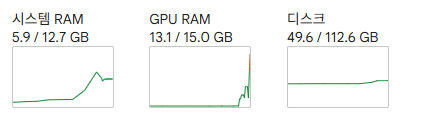